# Versao 9 - Pre-processamento

## Objetivo deste notebook

O pre-processamento da `versao9` reaproveita a base robusta da `versao8`, mas muda a forma como iremos interpretar os artefatos.

Agora, os dados preparados precisam servir simultaneamente para:

- a leitura sequencial por janelas da `LSTM` hibrida;
- a fusao com `X_tab`;
- a comparacao direta com `RandomForest` e `XGBoost`.

## Artefatos Da Ultima Execucao

A configuracao mais recente da `versao9` consolidou:

- amostras por split: `train = 1559`, `validation = 334`, `test = 335`
- colunas selecionadas para modelagem: `18`
- colunas continuas: `9`
- colunas de estado discreto: `9`
- comprimento fixo da sequencia: `120`
- atributos agregados em `X_tab`: `162`

A leitura importante para a `versao9` e que o novo modelo usa as duas representacoes ao mesmo tempo:

- `X_seq` para capturar a dinamica temporal por janelas;
- `X_tab` para complementar a rede com um resumo global da serie.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
PROJECT_ROOT = ROOT.parent if ROOT.name == "versao9" else ROOT

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
from versao9.pipeline_v9 import (
    BASE_TARGET_COLUMNS,
    clean_base_frame,
    load_bundle,
    load_split_arrays,
    prepare_classification_artifacts,
)

DATASET_ROOT = PROJECT_ROOT / "3W" / "dataset"
RUN_NAME = "classificacao_v9_lstm_hibrida"
SEQUENCE_LENGTH = 120
WINDOW_SIZE = 20
TRAIN_FRAC = 0.70
VALIDATION_FRAC = 0.15
RANDOM_STATE = 42

## Bloco explicito de pre-processamento

O objetivo das celulas seguintes e pedagogico: mostrar, no proprio notebook, como a serie e reamostrada, como o vetor `X_tab` e construido e como a sequencia e repartida em janelas para a `versao9`.

In [3]:
# ================================
# BLOCO DIDATICO DE PRE-PROCESSAMENTO
# ================================
# Mantemos aqui a mesma ideia da versao8, mas acrescentamos uma funcao
# que divide a serie em janelas temporais, porque isso passa a ser parte
# estrutural da arquitetura hibrida da versao9.

SERIES_STAT_NAMES_VISIBLE = [
    "mean",
    "std",
    "min",
    "max",
    "median",
    "first",
    "last",
    "slope",
    "mean_abs_diff",
]


def _safe_numeric_matrix_visible(values: np.ndarray, clip_abs: float = 1e12) -> np.ndarray:
    matrix = np.asarray(values, dtype=np.float64)
    matrix = np.clip(matrix, -clip_abs, clip_abs)
    matrix = np.nan_to_num(matrix, nan=0.0, posinf=0.0, neginf=0.0)
    return matrix


def resample_frame_to_fixed_length_visible(
    frame: pd.DataFrame,
    feature_columns: list[str],
    sequence_length: int,
    state_columns: list[str] | None = None,
) -> np.ndarray:
    state_columns = state_columns or []

    if sequence_length <= 0:
        raise ValueError("sequence_length precisa ser maior que zero.")
    if len(frame) == 0:
        raise ValueError("A serie nao pode estar vazia.")

    if len(frame) == 1:
        single_row = _safe_numeric_matrix_visible(frame[feature_columns].to_numpy(dtype=np.float64))
        return np.repeat(single_row, repeats=sequence_length, axis=0)

    source_pos = np.linspace(0.0, 1.0, len(frame), dtype=np.float64)
    target_pos = np.linspace(0.0, 1.0, sequence_length, dtype=np.float64)

    columns_resampled = []
    for column in feature_columns:
        values = pd.to_numeric(frame[column], errors="coerce").to_numpy(dtype=np.float64)

        if column in state_columns:
            interpolated_idx = np.interp(target_pos, source_pos, np.arange(len(frame), dtype=np.float64))
            nearest_idx = np.rint(interpolated_idx).astype(np.int64)
            nearest_idx = np.clip(nearest_idx, 0, len(frame) - 1)
            resampled = values[nearest_idx]
        else:
            resampled = np.interp(target_pos, source_pos, values)

        columns_resampled.append(resampled)

    return _safe_numeric_matrix_visible(np.stack(columns_resampled, axis=1))


def compute_statistical_feature_vector_visible(
    sequence_array: np.ndarray,
    feature_columns: list[str],
) -> np.ndarray:
    sequence = np.asarray(sequence_array, dtype=np.float64)
    if sequence.ndim != 2:
        raise ValueError("A sequencia precisa ter duas dimensoes: [tempo, features].")

    time_axis = np.arange(sequence.shape[0], dtype=np.float64)
    feature_values = []

    for feature_idx, _ in enumerate(feature_columns):
        values = sequence[:, feature_idx]
        if len(values) > 1:
            slope = float(np.polyfit(time_axis, values, deg=1)[0])
            mean_abs_diff = float(np.abs(np.diff(values)).mean())
        else:
            slope = 0.0
            mean_abs_diff = 0.0

        feature_values.extend(
            [
                float(values.mean()),
                float(values.std()),
                float(values.min()),
                float(values.max()),
                float(np.median(values)),
                float(values[0]),
                float(values[-1]),
                slope,
                mean_abs_diff,
            ]
        )

    return np.asarray(feature_values, dtype=np.float32)


def window_sequence_visible(sequence_array: np.ndarray, window_size: int) -> np.ndarray:
    sequence = np.asarray(sequence_array, dtype=np.float64)
    if sequence.ndim != 2:
        raise ValueError("A sequencia precisa ter formato [tempo, features].")
    if window_size <= 0:
        raise ValueError("window_size precisa ser maior que zero.")

    n_steps = sequence.shape[0]
    remainder = n_steps % window_size
    if remainder != 0:
        pad_steps = window_size - remainder
        pad_chunk = np.repeat(sequence[-1:, :], pad_steps, axis=0)
        sequence = np.vstack([sequence, pad_chunk])

    n_windows = sequence.shape[0] // window_size
    return sequence.reshape(n_windows, window_size, sequence.shape[1])

In [4]:
artifacts = prepare_classification_artifacts(
    dataset_root=DATASET_ROOT,
    run_name=RUN_NAME,
    train_frac=TRAIN_FRAC,
    validation_frac=VALIDATION_FRAC,
    random_state=RANDOM_STATE,
    sequence_length=SEQUENCE_LENGTH,
)

artifacts

PreparedClassificationArtifacts(run_dir='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v9/classificacao_v9_lstm_hibrida', bundle_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v9/classificacao_v9_lstm_hibrida/bundle_v9.json', manifest_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v9/classificacao_v9_lstm_hibrida/split_manifest_v6.csv', attribute_catalog_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v9/classificacao_v9_lstm_hibrida/catalogo_atributos.csv', event_catalog_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v9/classificacao_v9_lstm_hibrida/catalogo_eventos.csv', feature_selection_report_path='/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v9/classificacao_v9_lstm_hibrida/relatorio_selecao_de_features.csv', split_npz_paths={'train': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/reports_v9/classificacao_v9_lstm_hibrida/train_arrays.npz', 'validation': '/home/tiagoriosrocha/Desktop/lstm-w3/artifacts/repor

In [5]:
bundle = load_bundle(artifacts.bundle_path)
train_arrays = load_split_arrays(artifacts.split_npz_paths["train"])
val_arrays = load_split_arrays(artifacts.split_npz_paths["validation"])
test_arrays = load_split_arrays(artifacts.split_npz_paths["test"])

bundle_summary = pd.DataFrame(
    {
        "campo": [
            "selected_columns",
            "continuous_columns",
            "state_columns",
            "sequence_length",
            "statistical_feature_names",
            "split_counts",
        ],
        "valor": [
            bundle.selected_columns,
            bundle.continuous_columns,
            bundle.state_columns,
            bundle.sequence_length,
            len(bundle.statistical_feature_names),
            bundle.split_counts,
        ],
    }
)
display(bundle_summary)

,campo,valor
0,selected_columns,"[ESTADO-DHSV, ESTADO-M1, ESTADO-M2, ESTADO-PXO..."
1,continuous_columns,"[P-ANULAR, P-JUS-CKGL, P-MON-CKP, P-PDG, P-TPT..."
2,state_columns,"[ESTADO-DHSV, ESTADO-M1, ESTADO-M2, ESTADO-PXO..."
3,sequence_length,120
4,statistical_feature_names,162
5,split_counts,"{'test': 335, 'train': 1559, 'validation': 334}"


In [6]:
shape_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "X_seq_shape": [
            train_arrays["X_seq"].shape,
            val_arrays["X_seq"].shape,
            test_arrays["X_seq"].shape,
        ],
        "X_tab_shape": [
            train_arrays["X_tab"].shape,
            val_arrays["X_tab"].shape,
            test_arrays["X_tab"].shape,
        ],
        "y_shape": [
            train_arrays["y"].shape,
            val_arrays["y"].shape,
            test_arrays["y"].shape,
        ],
    }
)
display(shape_summary)

,split,X_seq_shape,X_tab_shape,y_shape
0,train,"(1559, 120, 18)","(1559, 162)","(1559,)"
1,validation,"(334, 120, 18)","(334, 162)","(334,)"
2,test,"(335, 120, 18)","(335, 162)","(335,)"


## O que a arquitetura vai consumir

Aqui aparece a grande diferenca da `versao9`:

- a `LSTM` nao usara apenas `X_seq`;
- ela tambem recebera `X_tab`;
- e, dentro de `X_seq`, fara uma leitura por janelas.

In [7]:
train_metadata = pd.read_csv(artifacts.split_metadata_paths["train"])
example_row = train_metadata.iloc[0]

example_frame = clean_base_frame(
    example_row["file_path"],
    target_columns=BASE_TARGET_COLUMNS,
    candidate_auxiliary_columns=[c for c in bundle.selected_columns if c not in BASE_TARGET_COLUMNS],
)

example_resampled = resample_frame_to_fixed_length_visible(
    example_frame,
    feature_columns=bundle.selected_columns,
    sequence_length=bundle.sequence_length,
    state_columns=bundle.state_columns,
)
example_windows = window_sequence_visible(example_resampled, WINDOW_SIZE)
example_stat_vector = compute_statistical_feature_vector_visible(
    example_resampled,
    bundle.selected_columns,
)

print("Shape apos reamostragem:", example_resampled.shape)
print("Shape apos divisao em janelas:", example_windows.shape)
print("Numero de descritores tabulares:", len(example_stat_vector))

Shape apos reamostragem: (120, 18)
Shape apos divisao em janelas: (6, 20, 18)
Numero de descritores tabulares: 162


In [8]:
feature_family_summary = pd.DataFrame(
    {
        "item": [
            "numero de colunas selecionadas",
            "colunas continuas",
            "colunas de estado discreto",
            "comprimento da sequencia",
            "tamanho da janela",
            "numero de janelas por amostra",
            "atributos finais em X_tab",
        ],
        "valor": [
            len(bundle.selected_columns),
            len(bundle.continuous_columns),
            len(bundle.state_columns),
            bundle.sequence_length,
            WINDOW_SIZE,
            bundle.sequence_length // WINDOW_SIZE,
            len(bundle.statistical_feature_names),
        ],
    }
)
display(feature_family_summary)

,item,valor
0,numero de colunas selecionadas,18
1,colunas continuas,9
2,colunas de estado discreto,9
3,comprimento da sequencia,120
4,tamanho da janela,20
5,numero de janelas por amostra,6
6,atributos finais em X_tab,162


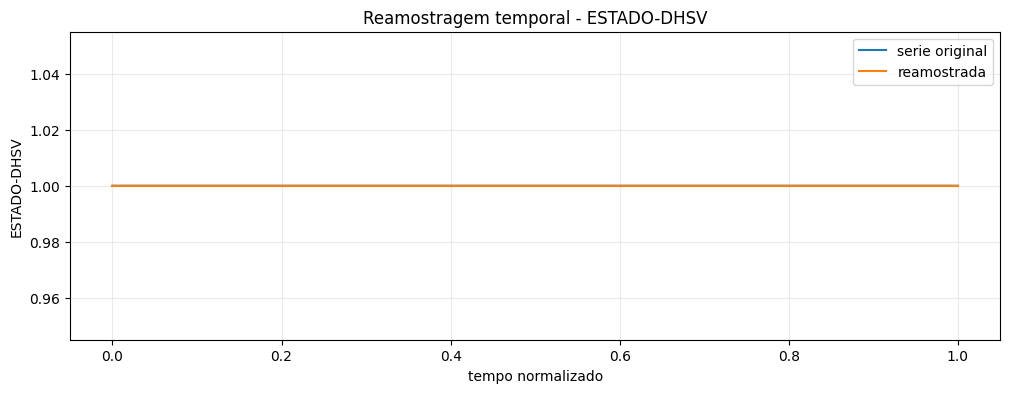

In [9]:
signal_name = bundle.selected_columns[0]
plt.figure(figsize=(12, 4))
plt.plot(np.linspace(0, 1, len(example_frame)), example_frame[signal_name].to_numpy(), label="serie original")
plt.plot(np.linspace(0, 1, bundle.sequence_length), example_resampled[:, 0], label="reamostrada")
plt.title(f"Reamostragem temporal - {signal_name}")
plt.xlabel("tempo normalizado")
plt.ylabel(signal_name)
plt.grid(alpha=0.25)
plt.legend()
plt.show()

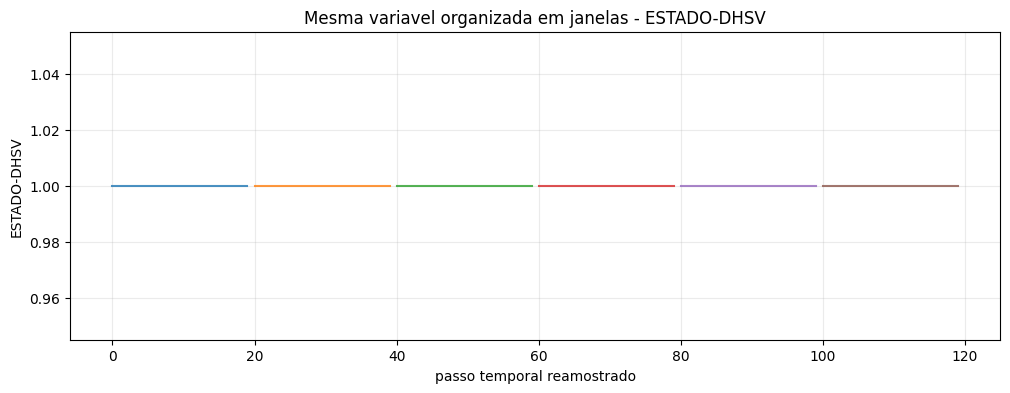

In [10]:
plt.figure(figsize=(12, 4))
for window_idx in range(example_windows.shape[0]):
    window_values = example_windows[window_idx, :, 0]
    x_values = np.arange(window_idx * WINDOW_SIZE, (window_idx + 1) * WINDOW_SIZE)
    plt.plot(x_values, window_values, alpha=0.8)
plt.title(f"Mesma variavel organizada em janelas - {signal_name}")
plt.xlabel("passo temporal reamostrado")
plt.ylabel(signal_name)
plt.grid(alpha=0.25)
plt.show()

## Fechamento do notebook

Ao final desta etapa, temos um ambiente perfeito para testar a nova hipotese da `versao9`:

- `X_seq` preserva a dinamica temporal;
- `X_tab` oferece informacao global condensada;
- a divisao em janelas prepara a leitura hierarquica da sequencia.